# 03 - Analise Textual Inicial

Objetivo: carregar uma amostra processada das integras do STJ, gerar estatisticas descritivas simples e produzir um relatorio exploratorio em Markdown.

Este notebook depende da amostra produzida por `02_validacao_integras_txt.ipynb`. Ainda nao faz comparacao com LLM, classificacao, fine-tuning ou conclusoes sobre vies.


In [15]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# No Colab, descomente as duas linhas abaixo.
# from google.colab import drive
# drive.mount('/content/drive')

DRIVE_DATA = Path('/content/drive/MyDrive/Mestrado/2026/llms/data')
PROCESSED_DATA = DRIVE_DATA / 'processed'
REPORTS_DATA = DRIVE_DATA / 'reports' / 'summaries'
FIGURES_DATA = DRIVE_DATA / 'reports' / 'figures'

for path in [PROCESSED_DATA, REPORTS_DATA, FIGURES_DATA]:
    path.mkdir(parents=True, exist_ok=True)

sample_path = PROCESSED_DATA / 'stj_integras_sample.parquet'
sample_path

PosixPath('/content/drive/MyDrive/Mestrado/2026/llms/data/processed/stj_integras_sample.parquet')

## 1. Carregar amostra

In [17]:
if sample_path.exists():
    df = pd.read_parquet(sample_path)
else:
    df = pd.read_csv(PROCESSED_DATA / 'stj_integras_sample.csv')

print(f'Amostra: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas')
df.head()

Amostra: 50 linhas x 11 colunas


,SeqDocumento,dataPublicacao,tipoDocumento,processo,ministro,NM_MINISTRO,teor,descricaoMonocratica,assuntos,texto_original,texto_limpo
0,362798716,2026-03-19,DECISÃO,HC 1078698,MARIA MARLUCE CALDAS,MARIA MARLUCE CALDAS,Negando,Denegado o Habeas Corpus de #{nome_da_parte} #...,00287.03603.03607.03608.,"DECISÃO<br>Trata-se de habeas corpus, com pedi...","DECISÃO\nTrata-se de habeas corpus, com pedido..."
1,360879614,2026-03-19,DECISÃO,HC 1057760,MARIA MARLUCE CALDAS,MARIA MARLUCE CALDAS,Concedendo,Não conhecido o Habeas Corpus. Concedido o Hab...,01209.07942.07791.,"DECISÃO<br>Trata-se de habeas corpus, com pedi...","DECISÃO\nTrata-se de habeas corpus, com pedido..."
2,364093156,2026-03-19,DECISÃO,HC 1079862,HERMAN BENJAMIN,HERMAN BENJAMIN,Negando,Denegado o Habeas Corpus de #{nome_da_parte} #...,00287.03415.03416.,DECISÃO<br>Cuida-se de Habeas Corpus impetrado...,DECISÃO\nCuida-se de Habeas Corpus impetrado e...
3,362865610,2026-03-19,DECISÃO,HC 1063902,SEBASTIÃO REIS JÚNIOR,SEBASTIÃO REIS JÚNIOR,Concedendo,Concedido o Habeas Corpus a #{nome_da_parte} #...,00287.03603.03607.03608.,DECISÃO<br>Trata-se de habeas corpus impetrado...,DECISÃO\nTrata-se de habeas corpus impetrado e...
4,363980237,2026-03-19,DECISÃO,HC 1080463,RIBEIRO DANTAS,RIBEIRO DANTAS,Não Conhecendo,Não conhecido o Habeas Corpus de #{nome_da_par...,00287.03415.05566.,DECISÃO<br>Trata-se de habeas corpus substitut...,DECISÃO\nTrata-se de habeas corpus substitutiv...


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SeqDocumento          50 non-null     int64 
 1   dataPublicacao        50 non-null     object
 2   tipoDocumento         50 non-null     object
 3   processo              50 non-null     object
 4   ministro              50 non-null     object
 5   NM_MINISTRO           50 non-null     object
 6   teor                  50 non-null     object
 7   descricaoMonocratica  50 non-null     object
 8   assuntos              49 non-null     object
 9   texto_original        50 non-null     object
 10  texto_limpo           50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


## 2. Estatisticas de texto

In [19]:
text_col = 'texto_limpo'

df[text_col] = df[text_col].fillna('').astype(str)
df['n_chars'] = df[text_col].str.len()
df['n_words'] = df[text_col].str.split().str.len()
df['texto_vazio'] = df[text_col].str.strip().eq('')

df[['n_chars', 'n_words']].describe()

,n_chars,n_words
count,50.000000,50.000000
mean,10560.960000,1613.580000
std,8063.733675,1232.525367
min,145.000000,21.000000
25%,4982.500000,744.000000
50%,9675.500000,1480.000000
75%,14189.750000,2204.000000
max,46768.000000,7169.000000


In [20]:
empty_share = df['texto_vazio'].mean() if len(df) else np.nan
print(f'Percentual de textos vazios: {empty_share:.2%}')

Percentual de textos vazios: 0.00%


## 3. Distribuicoes dos metadados

In [21]:
def value_counts_safe(df: pd.DataFrame, column: str, n: int = 20) -> pd.Series:
    if column not in df.columns:
        return pd.Series(dtype='int64', name=column)
    return df[column].fillna('(vazio)').astype(str).value_counts().head(n)

tipo_counts = value_counts_safe(df, 'tipoDocumento')
ministro_counts = value_counts_safe(df, 'ministro')
teor_counts = value_counts_safe(df, 'teor')

tipo_counts

,count
tipoDocumento,
DECISÃO,50


In [22]:
ministro_counts

,count
ministro,
HERMAN BENJAMIN,11
RIBEIRO DANTAS,9
OG FERNANDES,7
JOEL ILAN PACIORNIK,5
REYNALDO SOARES DA FONSECA,4
SEBASTIÃO REIS JÚNIOR,4
MARIA MARLUCE CALDAS,3
CARLOS PIRES BRANDÃO,3
ANTONIO SALDANHA PALHEIRO,3


In [23]:
teor_counts

,count
teor,
Negando,26
Não Conhecendo,17
Concedendo,5
Outros,2


## 4. Graficos simples

PosixPath('/content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/stj_integras_tamanho_textos.png')

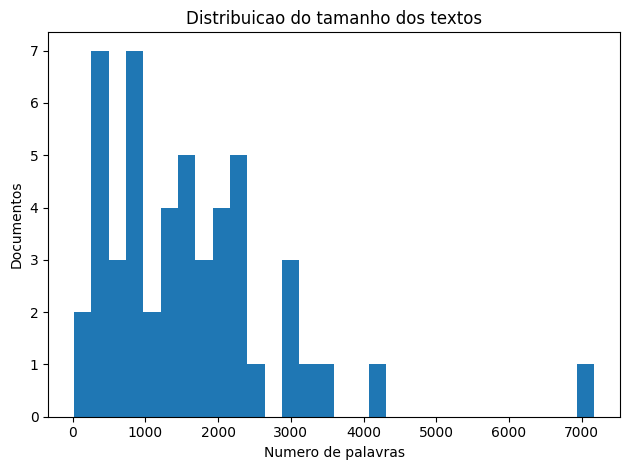

In [24]:
ax = df['n_words'].plot(kind='hist', bins=30, title='Distribuicao do tamanho dos textos')
ax.set_xlabel('Numero de palavras')
ax.set_ylabel('Documentos')
plt.tight_layout()
figure_path = FIGURES_DATA / 'stj_integras_tamanho_textos.png'
plt.savefig(figure_path, dpi=150)
figure_path

## 5. Termos frequentes preliminares

Esta contagem e apenas exploratoria. Nao aplicar stopwords, stemming ou lematizacao nesta fase sem decisao metodologica explicita.

In [25]:
def tokenize_basic(text: str) -> list[str]:
    return re.findall(r'\b[\wÀ-ÿ]{3,}\b', text.lower())

counter = Counter()
for text in df[text_col]:
    counter.update(tokenize_basic(text))

common_terms = pd.DataFrame(counter.most_common(50), columns=['termo', 'frequencia'])
common_terms.head(20)

,termo,frequencia
0,que,1561
1,não,942
2,para,567
3,por,485
4,com,454
5,art,414
6,turma,389
7,habeas,378
8,corpus,378
9,dos,338


## 6. Exemplos para leitura qualitativa

In [26]:
cols = [c for c in ['SeqDocumento', 'tipoDocumento', 'ministro', 'teor', 'processo', 'n_words'] if c in df.columns]
df.sort_values('n_words', ascending=False)[cols].head(10)

,SeqDocumento,tipoDocumento,ministro,teor,processo,n_words
9,363748950,DECISÃO,REYNALDO SOARES DA FONSECA,Não Conhecendo,HC 1069090,7169
30,363666889,DECISÃO,OG FERNANDES,Não Conhecendo,HC 1071333,4162
8,364136100,DECISÃO,RIBEIRO DANTAS,Negando,RHC 233301,3442
20,362754007,DECISÃO,RIBEIRO DANTAS,Não Conhecendo,RHC 224137,3122
5,364305370,DECISÃO,JOEL ILAN PACIORNIK,Concedendo,HC 1081023,2960
32,362806326,DECISÃO,MARIA MARLUCE CALDAS,Negando,RHC 233576,2938
36,364269152,DECISÃO,RIBEIRO DANTAS,Não Conhecendo,HC 1080707,2910
46,364208644,DECISÃO,ANTONIO SALDANHA PALHEIRO,Negando,HC 1069089,2433
38,364087686,DECISÃO,JOEL ILAN PACIORNIK,Não Conhecendo,HC 1076885,2377
7,364282861,DECISÃO,CARLOS PIRES BRANDÃO,Negando,RHC 234169,2321


In [27]:
example = df.sort_values('n_words', ascending=False).iloc[0]
print('SeqDocumento:', example.get('SeqDocumento'))
print('Tipo:', example.get('tipoDocumento'))
print('Ministro:', example.get('ministro'))
print('\nTrecho inicial:\n')
print(example[text_col][:3000])

SeqDocumento: 363748950
Tipo: DECISÃO
Ministro: REYNALDO SOARES DA FONSECA

Trecho inicial:

DECISÃO
Trata-se de habeas corpus, com pedido liminar, impetrado em favor de DENNER DIAS POGORZELSKI apontando como autoridade coatora o Tribunal de Justiça do Estado do Rio Grande do Sul (Apelação Criminal n. 5001975-42.2019.8.21.0067).
Consta dos autos que o paciente foi condenado como incurso no art. 157, §2º, inciso II, e §2º-A, I, do Código Penal, à pena de 11 anos e 22 dias de reclusão, em regime fechado. Irresignada, a defesa interpôs recurso de apelação, o qual foi parcialmente provido apenas para redimensionar a pena para 7 anos, 1 mês e 5 dias de reclusão, em regime semiaberto, julgado nos termos da seguinte ementa (e-STJ fls. 715-716):
DIREITO PENAL. APELAÇÃO CRIMINAL. ROUBO MAJORADO. EMPREGO DE ARMA DE FOGO. CONCURSO DE AGENTES. AUTORIA INTELECTUAL. CONDENAÇÃO MANTIDA. REDIMENSIONAMENTO DA PENA. RECURSO PARCIALMENTE PROVIDO.
I. CASO EM EXAME:
1. Apelação criminal interposta contra s

## 7. Relatorio exploratorio

In [28]:
def series_to_markdown(series: pd.Series) -> str:
    if series.empty:
        return '_Coluna ausente ou sem valores._'
    table = series.rename_axis('valor').reset_index(name='n')
    return table.to_markdown(index=False)

summary = df[['n_chars', 'n_words']].describe().round(2)
empty_pct = df['texto_vazio'].mean() * 100 if len(df) else 0

report = f'''# Relatorio exploratorio - STJ Integras

## Escopo

Analise inicial de amostra processada da base STJ - Integras de Decisoes Terminativas e Acordaos do Diario da Justica.

## Totais

- Total de documentos na amostra: {len(df):,}
- Percentual de textos vazios: {empty_pct:.2f}%
- Tamanho medio em caracteres: {df['n_chars'].mean():.2f}
- Tamanho minimo em caracteres: {df['n_chars'].min()}
- Tamanho maximo em caracteres: {df['n_chars'].max()}
- Tamanho medio em palavras: {df['n_words'].mean():.2f}

## Distribuicao por tipo de documento

{series_to_markdown(tipo_counts)}

## Distribuicao por ministro

{series_to_markdown(ministro_counts)}

## Distribuicao por teor

{series_to_markdown(teor_counts)}

## Estatisticas de tamanho

{summary.to_markdown()}

## Observacoes preliminares sobre qualidade da base

- Verificar se a amostra e representativa antes de extrapolar achados.
- Conferir manualmente documentos com texto vazio ou muito curto.
- Validar se `SeqDocumento` mantem alta cobertura entre metadados e TXT.
- Evitar conclusoes sobre vies ou comportamento de LLM nesta etapa.
'''

report_path = REPORTS_DATA / 'eda_summary.md'
report_path.write_text(report, encoding='utf-8')
report_path

PosixPath('/content/drive/MyDrive/Mestrado/2026/llms/data/reports/summaries/eda_summary.md')

## 8. Proximos passos

- Aumentar a amostra se a ligacao por `SeqDocumento` estiver consistente.
- Mover funcoes estaveis para `src/`.
- Definir criterios de recorte por tipo de documento, teor, ministro ou assunto.
- So depois avaliar embeddings, clustering ou comparacoes com LLM.